In [1]:
from langgraph.graph import StateGraph,START,END
import os
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from dotenv import load_dotenv
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing import TypedDict,List,Literal
from langchain_community.vectorstores import FAISS
from pydantic import BaseModel,Field
from langchain_openai import ChatOpenAI,OpenAIEmbeddings


c:\Coding\Python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
llm = ChatOpenAI(
    model="nvidia/nemotron-3-super-120b-a12b:free",
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1",
)

In [4]:
docs=(
    PyPDFLoader("./Documents/Company_Policies.pdf").load()+
    PyPDFLoader("./Documents/Company_Profile.pdf").load()+
    PyPDFLoader("./Documents/Product_and_pricing.pdf").load()
)

In [5]:
chunks=RecursiveCharacterTextSplitter(chunk_size=600,chunk_overlap=150).split_documents(docs)

In [6]:
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1"
)

In [7]:
vector_store=FAISS.from_documents(chunks,embeddings)

In [8]:
rtriever=vector_store.as_retriever(search_kwargs={"k":3})

In [9]:
class State(TypedDict):
    question:str
    need_retrieval:bool

    docs:List[Document]
    relevant_docs:List[Document]

    context:str
    answer:str

    issup:Literal["fully_supported", "partially_supported", "no_support"]
    evidence:List[str]
    
    retries:int

    isuse:Literal["useful","not_useful"]
    use_reason:str

In [10]:
class RetrieveDecision(BaseModel):
    should_retrieve:bool=Field(
        description="True if exteral documentds are needed to answer reliably,else false."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

should_retrieve_llm=llm.with_structured_output(RetrieveDecision)

In [11]:
def decide(state:State):
    descision:RetrieveDecision=should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state['question'])
    )
    return {
        "need_retrieval":descision.should_retrieve
    }

In [12]:
def route_after_decide(state:State)->Literal["Generate","Retrieve"]:
    if state["need_retrieval"]:
        return "Retrieve"
    return "Generate"

In [13]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)

def generate(state:State):
    out=llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer":out.content
    }

In [14]:
def retrieve(state:State):
    return {
        "docs":rtriever.invoke(state["question"])
    }

In [38]:
class RelevenceDecision(BaseModel):
    is_relevant:bool=Field(
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it directly answers the question OR contains information related to the topic of the question. Be generous. If there is any connection, return true."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

relevence_llm=llm.with_structured_output(RelevenceDecision)

def is_relevent(state:State):
    relevant_docs :List[Document]=[]

    for doc in state["docs"]:
        descision:RelevenceDecision=relevence_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content
            )
        )

        if descision.is_relevant:
            relevant_docs.append(doc)

    return {
        "relevant_docs":relevant_docs 
    }

In [39]:
def route_after_relevence(state:State)->Literal["From Relevent Docs","No Relevent Docs"]:
    if state.get("relevant_docs") and len(state["relevant_docs"])>0:
        return "From Relevent Docs"
    return "No Relevent Docs"

In [40]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

In [41]:
def generate_from_contex(state:State):
    context="\n\n---\n\n".join(
        [d.page_content for d in state.get("relevant_docs",[])]
    ).strip()

    if not context:
        return {
            "answer":"No relevant document found.",
            "context": ""
        }
    
    out=llm.invoke(
        rag_generation_prompt.format_messages(
            question=state["question"],
            context=context
        )
    )
    return {
        "answer":out.content,
        "context":context
    }

In [42]:
def no_answer_docs(state:State):
    return {
        "answer": "No relevant document found.",
        "context": ""
    }

In [43]:
class IsSUPDescision(BaseModel):
    issup:Literal["fully_supported", "partially_supported", "no_support"]
    evidence:List[str]=Field(default_factory=list)

issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

issup_llm=llm.with_structured_output(IsSUPDescision)

In [44]:
def is_sup(state:State):
    descision:IsSUPDescision=issup_llm.invoke(
        issup_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer",""),
            context=state.get("context","")
        )
    )
    return {
        "issup":descision.issup,
        "evidence":descision.evidence
    }

In [45]:
MAX_RERIES=10

def route_after_issup(state:State)->Literal["Accept","Revise"]:
    if state.get("issup")=="fully_supported":
        return "Accept"
    
    if state.get("retries",0)>=MAX_RERIES:
        return "Accept"
    
    return "Revise"

In [46]:
def accept_answer(state:State):
    return {}

In [47]:
revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)

In [48]:
def revise_answer(state:State):
    out=llm.invoke(
        revise_prompt.format_messages(
            question=state['question'],
            answer=state.get("answer",""),
            context=state.get("context","")
        )
    )

    return {
        "answer":out.content,
        "retries":state.get("retries",0)+1
    }

In [49]:
class IsUSEDecision(BaseModel):
    isuse:Literal["useful","not_useful"]
    reason:str=Field(description="Short reason in 1 line")

isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        ),
    ]
)

isuse_llm=llm.with_structured_output(IsUSEDecision)

In [50]:
def is_use(state:State):
    decision:IsUSEDecision=isuse_llm.invoke(
        isuse_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer","")
        )
    )
    return {
        "isuse":decision.isuse,
        "use_reason":decision.reason
    }

In [51]:
def route_after_isuse(state:State)->Literal["END","No Relevent Docs"]:
    if state.get("isuse")=="useful":
        return "END"
    return "No Relevent Docs"

In [52]:
g=StateGraph(State)

g.add_node("Decide",decide)
g.add_node("Generate",generate)

g.add_node("Relevent",is_relevent)
g.add_node("Retrieve",retrieve)

g.add_node("From Relevent Docs",generate_from_contex)
g.add_node("No Relevent Docs",no_answer_docs)

g.add_node("Is Supportive",is_sup)

g.add_node("Accept",accept_answer)
g.add_node("Revise",revise_answer)

g.add_node("Is use",is_use)

g.add_edge(START,"Decide")
g.add_conditional_edges(
    "Decide",
    route_after_decide,
    {
        "Retrieve":"Retrieve",
        "Generate":"Generate"
    }
)

g.add_edge("Generate",END)

g.add_edge("Retrieve","Relevent")

g.add_conditional_edges(
    "Relevent",
    route_after_relevence,
    {
        "From Relevent Docs":"From Relevent Docs",
        "No Relevent Docs":"No Relevent Docs"
    }
)
g.add_edge("From Relevent Docs","Is Supportive")

g.add_conditional_edges(
    "Is Supportive",
    route_after_issup,
    {
        "Accept":"Is use",
        "Revise":"Revise"
    }
)

g.add_edge("Revise","Is Supportive")
g.add_conditional_edges(
    "Is use",
    route_after_isuse,
    {
        "END":END,
        "No Relevent Docs":"No Relevent Docs"
    }
)

g.add_edge("No Relevent Docs",END)

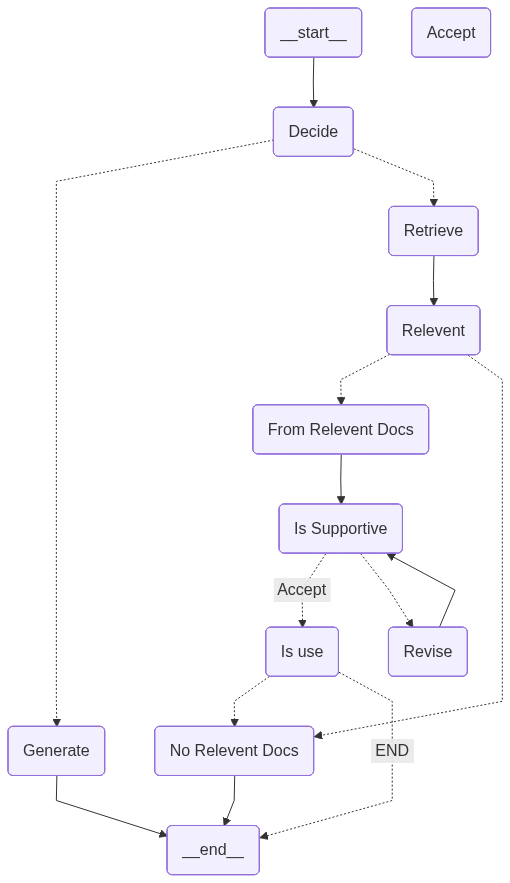

In [53]:
app=g.compile()
app

In [54]:
# -----------------------------
# Run the graph
# -----------------------------
initial_state = {
    "question": "What is refund policy of NexaAI",
    "docs": [],
    "relevant_docs": [],
    "context": "",
    "answer": "",
    "issup": "",
    "evidence": [],
    "retries": 0,
}

result = app.invoke(
    initial_state,
    config={"recursion_limit": 80},  # allow revise → verify loops
)

# -----------------------------
# Debug / inspection output
# -----------------------------
print("\n===== RAG EXECUTION RESULT =====\n")

print("Question:", initial_state["question"])
print("Need Retrieval:", result.get("need_retrieval"))

print("\nRetrieval:")
print("  Total retrieved docs:", len(result.get("docs", [])))
print("  Relevant docs:", len(result.get("relevant_docs", [])))

print("\nVerification (IsSUP):")
print("  issup:", result.get("issup"))
print("  evidence:")
for e in result.get("evidence", []):
    print("   -", e)

print("Final Answer:", result.get("answer"))
print("Usefulness Status - ", result.get("isuse"))
print("Usefulness Reason ", result.get("use_reason"))

print("\nRetries used:", result.get("retries", 0))
print("\n===============================\n")


===== RAG EXECUTION RESULT =====

Question: What is refund policy of NexaAI
Need Retrieval: True

Retrieval:
  Total retrieved docs: 3
  Relevant docs: 0

Verification (IsSUP):
  issup: 
  evidence:
Final Answer: No relevant document found.
Usefulness Status -  None
Usefulness Reason  None

Retries used: 0




In [35]:
result['need_retrieval']

True

In [36]:
for doc in result['docs']:
    print(doc.page_content)
    print("*"*100)

NexaAI Solutions – Company Policies
HR Policies
NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
All employment decisions are made without discrimination.

Equal opportunity employer

Bi-annual performance reviews

Clear career progression framework

Strict anti-harassment policy
Leave Policy
Employees are encouraged to maintain a healthy work-life balance.

Annual Leave: 18 working days per year

Sick Leave: 10 working days per year

Casual Leave: 6 working days per year

Maternity Leave: As per statutory norms

****************************************************************************************************
NexaAI Solutions – Company Profile
Company Overview
NexaAI Solutions Pvt. Ltd. is a business-focused artificial intelligence company founded in 2021.
The company specializes in building enterprise-ready AI systems for knowledge management,
analytics, and automation.
NexaAI primarily serves mid-sized and large organizations across 

In [37]:
from pprint import pprint
pprint(result)

{'answer': 'No relevant document found.',
 'context': '',
 'docs': [Document(id='75c5b7f7-205f-42ae-995f-b7a83dfb60dd', metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-14T13:07:17+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': './Documents/Company_Policies.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='NexaAI Solutions – Company Policies\nHR Policies\nNexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.\nAll employment decisions are made without discrimination.\n\x7f\nEqual opportunity employer\n\x7f\nBi-annual performance reviews\n\x7f\nClear career progression framework\n\x7f\nStrict anti-harassment policy\nLeave Policy\nEmployees are encouraged to maintain a healthy work-life balance.\n\x7f\nAnnual Leave: 18 working days per year\n\x